In [ ]:
#descompactar zip
import zipfile
import os

zip_path = "/content/srcim_yolo_dataset.zip"
extract_path = "/content/exported_dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extraído para:", extract_path)
print("Conteúdo:")
print(os.listdir(extract_path))

Dataset extraído para: /content/exported_dataset
Conteúdo:
['images', 'classes.txt', 'notes.json', 'labels']


In [ ]:
#preparar o dataset
import shutil
import random
from pathlib import Path

source_dir = Path("/content/exported_dataset")
source_images = source_dir / "images"
source_labels = source_dir / "labels"

final_dir = Path("/content/srcim_yolo_dataset")
data_dir = final_dir / "data"

train_images = data_dir / "train" / "images"
train_labels = data_dir / "train" / "labels"
val_images = data_dir / "val" / "images"
val_labels = data_dir / "val" / "labels"

for folder in [train_images, train_labels, val_images, val_labels]:
    folder.mkdir(parents=True, exist_ok=True)

image_extensions = [".jpg", ".jpeg", ".png", ".bmp"]
images = []

for ext in image_extensions:
    images.extend(source_images.glob(f"*{ext}"))

print("Imagens encontradas:", len(images))

random.seed(42)
random.shuffle(images)

split_index = int(0.8 * len(images))
train_set = images[:split_index]
val_set = images[split_index:]

def copy_image_and_label(image_path, images_dest, labels_dest):
    shutil.copy(image_path, images_dest / image_path.name)

    label_path = source_labels / (image_path.stem + ".txt")
    dest_label_path = labels_dest / (image_path.stem + ".txt")

    if label_path.exists():
        shutil.copy(label_path, dest_label_path)
    else:
        dest_label_path.write_text("")
        print("Label não encontrada para:", image_path.name)

for img in train_set:
    copy_image_and_label(img, train_images, train_labels)

for img in val_set:
    copy_image_and_label(img, val_images, val_labels)

print("Treino:", len(train_set))
print("Validação:", len(val_set))

Imagens encontradas: 219
Treino: 175
Validação: 44


In [ ]:
#verificações
from pathlib import Path

lbl_dir = Path("/content/srcim_yolo_dataset/data/train/labels")

labels = list(lbl_dir.glob("*.txt"))
labels_with_content = [l for l in labels if l.read_text().strip()]

print("Total de labels:", len(labels))
print("Labels com conteúdo:", len(labels_with_content))

for l in labels_with_content[:5]:
    print(l.name, "->", l.read_text().strip())

Total de labels: 175
Labels com conteúdo: 150
98f19769-03402da3-product79.txt -> 0 0.4342532467532467 0.18668831168831168 0.3003246753246753 0.045454545454545435
f758104a-31d91a9d-product231.txt -> 0 0.3928571428571429 0.44480519480519476 0.09415584415584412 0.5162337662337663
badd31b7-3d0eee42-product220.txt -> 0 0.6737012987012987 0.19399350649350652 0.40909090909090906 0.05032467532467532
6856c59b-5e50557b-product119.txt -> 0 0.3758116883116883 0.48133116883116883 0.06655844155844165 0.5178571428571428
491a2416-e3ac41e6-product136.txt -> 0 0.32629870129870125 0.38879870129870125 0.461038961038961 0.14123376623376627


In [ ]:
#criar o ficheiro que diz ao yolo onde esta o dataset e quais clases ele deve aprender
yaml_content = """
path: /content/srcim_yolo_dataset/data
train: train/images
val: val/images

names:
  0: defect
"""

yaml_path = "/content/srcim_yolo_dataset/data/dataset.yaml"

with open(yaml_path, "w") as f:
    f.write(yaml_content)

print("dataset.yaml criado em:", yaml_path)
print(yaml_content)

dataset.yaml criado em: /content/srcim_yolo_dataset/data/dataset.yaml

path: /content/srcim_yolo_dataset/data
train: train/images
val: val/images

names:
  0: defect



In [ ]:
#confirmar se para cada imagem existe um label .txt correspondente
from pathlib import Path

for split in ["train", "val"]:
    img_dir = Path(f"/content/srcim_yolo_dataset/data/{split}/images")
    lbl_dir = Path(f"/content/srcim_yolo_dataset/data/{split}/labels")

    images = list(img_dir.glob("*"))
    labels = list(lbl_dir.glob("*.txt"))

    print(f"{split}:")
    print(" imagens:", len(images))
    print(" labels:", len(labels))

    missing = []
    for img in images:
        label = lbl_dir / (img.stem + ".txt")
        if not label.exists():
            missing.append(img.name)

    if missing:
        print(" Imagens sem label:", missing[:10])
    else:
        print(" Todas as imagens têm ficheiro .txt")

train:
 imagens: 175
 labels: 175
 Todas as imagens têm ficheiro .txt
val:
 imagens: 44
 labels: 44
 Todas as imagens têm ficheiro .txt


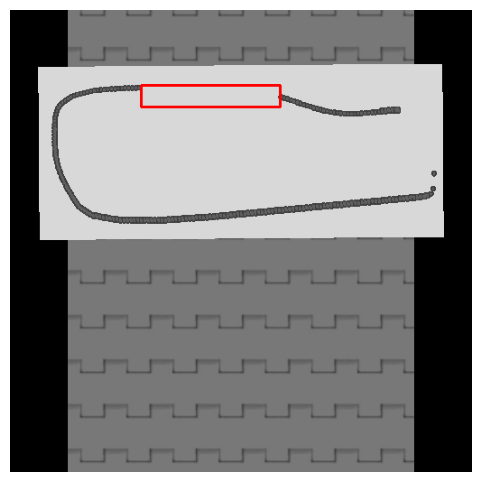

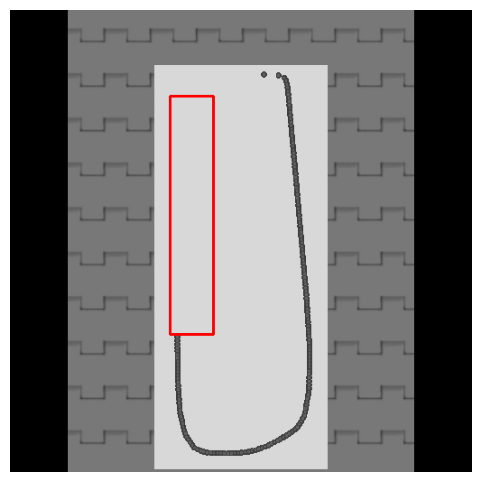

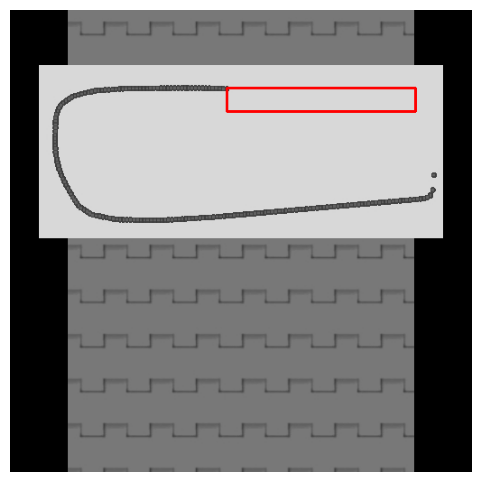

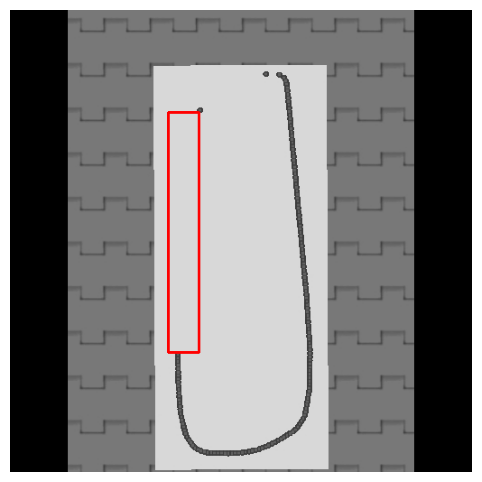

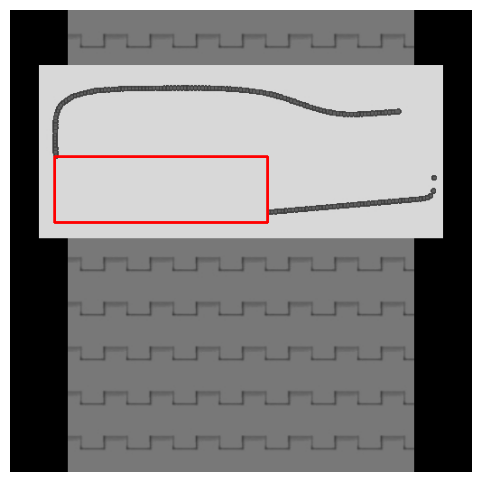

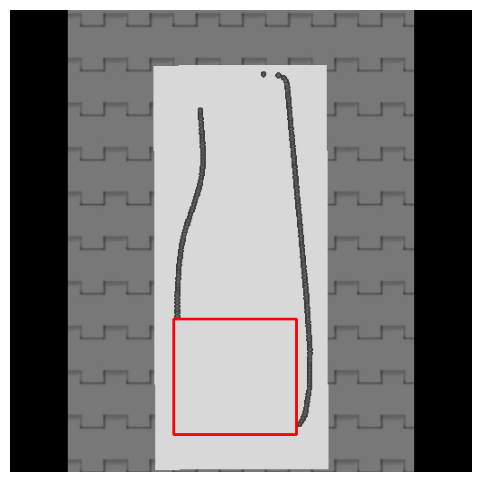

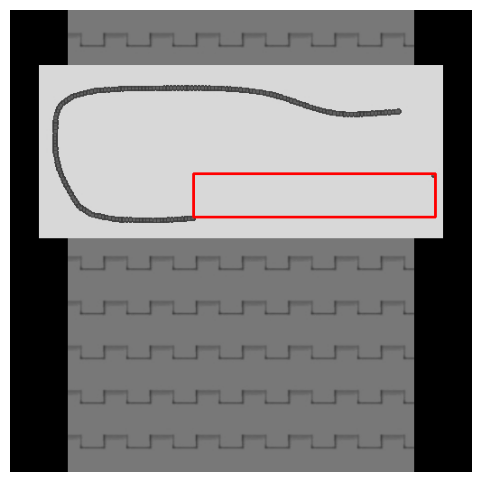

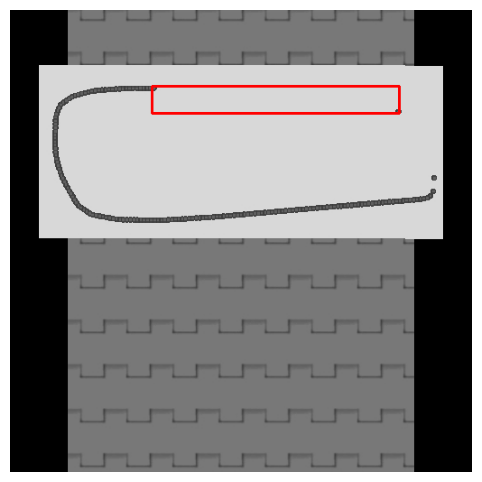

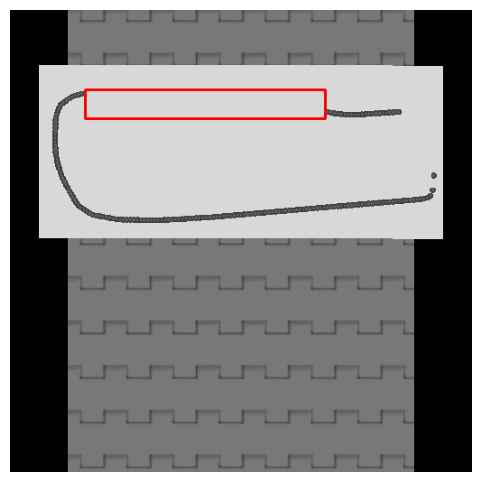

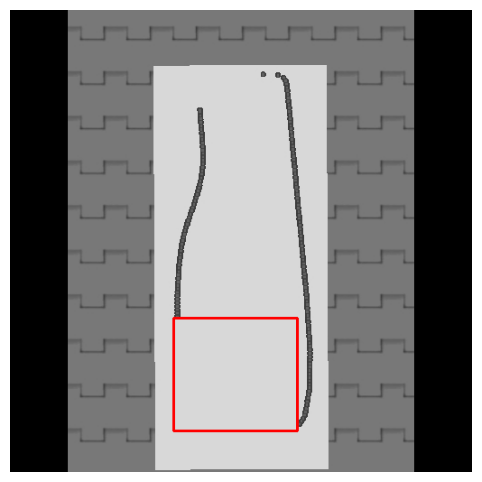

In [ ]:
#verificações
import cv2
from pathlib import Path
import matplotlib.pyplot as plt

def show_yolo_label(image_path, label_path):
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    for line in label_path.read_text().strip().splitlines():
        cls, x, y, bw, bh = map(float, line.split())
        x1 = int((x - bw / 2) * w)
        y1 = int((y - bh / 2) * h)
        x2 = int((x + bw / 2) * w)
        y2 = int((y + bh / 2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

img_dir = Path("/content/srcim_yolo_dataset/data/train/images")
lbl_dir = Path("/content/srcim_yolo_dataset/data/train/labels")

count = 0
for label_file in lbl_dir.glob("*.txt"):
    if label_file.read_text().strip():
        img_candidates = list(img_dir.glob(label_file.stem + ".*"))
        if img_candidates:
            show_yolo_label(img_candidates[0], label_file)
            count += 1
        if count == 10:
            break

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.9 MB/s eta 0:00:00


In [ ]:
#treino
from ultralytics import YOLO

model = YOLO("yolo26s.pt")

results = model.train(
    data="/content/srcim_yolo_dataset/data/dataset.yaml",
    epochs=150,
    imgsz=640,
    batch=16,
    box=8.5,
    cls=1.5,
    nbs=64,
    patience=30,
    name="srcim_defect_yolo26s_640_150"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.55 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=8.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=1.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/srcim_yolo_dataset/data/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=

In [ ]:
#validar o modelo e dizer as metricas
from ultralytics import YOLO

best_model = YOLO("/content/runs/detect/srcim_defect_yolo26s_640_150/weights/best.pt")

metrics = best_model.val(
    data="/content/srcim_yolo_dataset/data/dataset.yaml",
    imgsz=640
)

Ultralytics 8.4.55 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s summary (fused): 122 layers, 9,465,567 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1739.9±527.8 MB/s, size: 36.8 KB)
val: Scanning /content/srcim_yolo_dataset/data/val/labels.cache... 44 images, 6 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 44/44 16.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.1it/s 2.8s
                   all         44         38      0.611      0.658      0.702       0.35
Speed: 17.7ms preprocess, 23.3ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /content/runs/detect/val


In [ ]:
#escolher uma imagem do dataset para testar o modelo
import os
from pathlib import Path

val_images = list(Path("/content/srcim_yolo_dataset/data/val/images").glob("*"))
test_image = str(val_images[0])

print(test_image)

/content/srcim_yolo_dataset/data/val/images/4ba6a3cf-a8c1b2b1-product242.jpg



image 1/1 /content/srcim_yolo_dataset/data/val/images/4ba6a3cf-a8c1b2b1-product242.jpg: 640x640 (no detections), 16.7ms
Speed: 3.7ms preprocess, 16.7ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


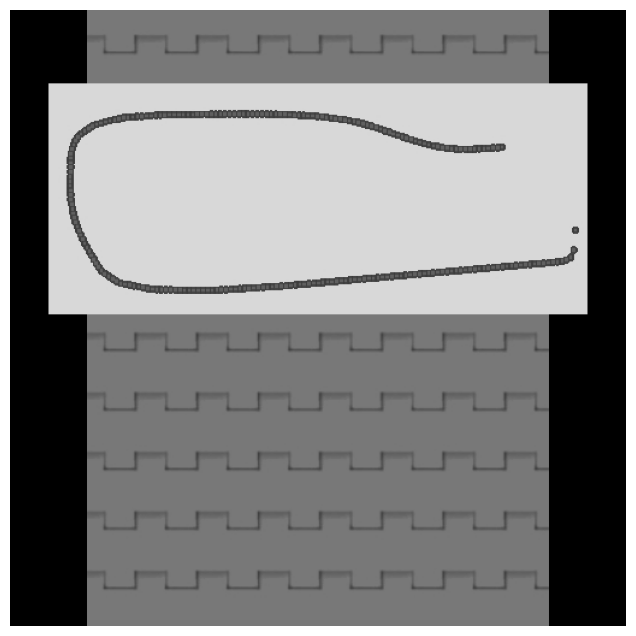

In [ ]:
#testar o modelo
best_model = YOLO("/content/runs/detect/srcim_defect_yolo26s_640_150/weights/best.pt")

results = best_model.predict(
    source=test_image,
    conf=0.2,
    iou=0.30,
    max_det=3,
    save=True

)
import matplotlib.pyplot as plt

result_img = results[0].plot()

plt.figure(figsize=(8, 8))
plt.imshow(result_img)
plt.axis("off")
plt.show()

In [ ]:
#encontrar modelo
!find /content/runs -name "best.pt"

/content/runs/detect/srcim_defect_yolo26s_640_150/weights/best.pt


In [ ]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/srcim_defect_yolo26s_640_150/weights/best.pt")

model.export(
    format="onnx",
    imgsz=640,
    opset=12,
    simplify=True
)

Ultralytics 8.4.55 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO26s summary (fused): 122 layers, 9,465,567 parameters, 0 gradients, 20.5 GFLOPs

PyTorch: starting from '/content/runs/detect/srcim_defect_yolo26s_640_150/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (19.4 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 326ms
Prepared 4 packages in 1.65s
Installed 4 packages in 566ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime==1.26.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 3.3s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset

/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset11.py:954: UserWarning: Exporting aten::index operator of advanced indexing in opset 12 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  return opset9.index(g, self, index)


ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 10.0s, saved as '/content/runs/detect/srcim_defect_yolo26s_640_150/weights/best.onnx' (36.4 MB)

Export complete (11.4s)
Results saved to /content/runs/detect/srcim_defect_yolo26s_640_150/weights/best.onnx
Predict:         yolo predict task=detect model=/content/runs/detect/srcim_defect_yolo26s_640_150/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/content/runs/detect/srcim_defect_yolo26s_640_150/weights/best.onnx imgsz=640 data=/content/srcim_yolo_dataset/data/dataset.yaml  
Visualize:       https://netron.app


'/content/runs/detect/srcim_defect_yolo26s_640_150/weights/best.onnx'

In [ ]:
from google.colab import files

files.download("/content/runs/detect/srcim_defect_yolo26s_640_150/weights/best.onnx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#baixar o zip do modelo
!zip -j /content/best_model.zip /content/runs/detect/srcim_defect_yolo26s_640_150/weights/best.pt
from google.colab import files
files.download("/content/best_model.zip")

updating: best.pt (deflated 8%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>